# 02 - OCR Text + Layout Features

This notebook implements Person 2 architecture using shared OCR infrastructure from `src/ocr_engine.py`.
We compare three leakage-safe models:
1. Text-only
2. Layout-only
3. Text + Layout

Target classes: `invoice`, `form`, `resume`, `email`, `budget`.

## Leakage Prevention

- TF-IDF vectorizers are fit on **train only**.
- Layout imputer/scaler are fit on **train only**.
- Validation is used for model comparison and selection.
- Test is used only after selection for final reporting.

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import load_ocr_config
from src.ocr_engine import load_ocr_text, ocr_batch
from src.layout_features import build_layout_feature_table
from src.models_layout import (
    TextVectorizerConfig,
    fit_text_vectorizers,
    transform_text_features,
    fit_layout_preprocessor,
    transform_layout_features,
    fit_text_only_model,
    fit_layout_only_model,
    fit_text_layout_model,
    combine_text_layout_features,
    predict_labels_and_proba,
    build_prediction_table,
    save_model_bundle,
    save_artifact,
)
from src.evaluation import (
    compute_metrics,
    metrics_dict_to_frame,
    confusion_matrix_df,
    plot_confusion_matrix,
    classification_report_df,
)

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

cfg = load_ocr_config(PROJECT_ROOT / 'configs' / 'config.yaml')
# Ensure paths are rooted at project, even when notebook cwd is notebooks/.
cfg.cache_dir = str(PROJECT_ROOT / 'data' / 'interim' / 'ocr')
cfg.diagnostics_dir = str(PROJECT_ROOT / 'outputs' / 'ocr_diagnostics')

models_dir = PROJECT_ROOT / 'models' / 'layout'
pred_dir = PROJECT_ROOT / 'outputs' / 'predictions'
fig_dir = PROJECT_ROOT / 'reports' / 'figures'
table_dir = PROJECT_ROOT / 'reports' / 'tables'
layout_feat_dir = PROJECT_ROOT / 'data' / 'interim' / 'layout_features'
for p in [models_dir, pred_dir, fig_dir, table_dir, layout_feat_dir]:
    p.mkdir(parents=True, exist_ok=True)

LABELS = ['invoice', 'form', 'resume', 'email', 'budget']

## Load Data Splits

In [3]:
train_df = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'train.csv')
val_df = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'val.csv')
test_df = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'test.csv')

required_cols = {'doc_id', 'file_path', 'class_name'}
for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f'{name} split missing columns: {missing}')

for df, split_name in [(train_df, 'train'), (val_df, 'val'), (test_df, 'test')]:
    if 'split' not in df.columns:
        df['split'] = split_name

split_summary = pd.concat([train_df, val_df, test_df], ignore_index=True).groupby(['split','class_name']).size().unstack(fill_value=0)
split_summary

class_name,budget,email,form,invoice,resume
split,,,,,
test,376,377,376,372,380
train,1753,1761,1754,1734,1775
val,376,378,376,371,381


## OCR Cache Check
This notebook assumes notebook 01 has already built full OCR cache for train/val/test.
You can optionally fill missing OCR here, but canonical strategy is to do it in notebook 01.

In [4]:
all_meta = pd.concat([train_df, val_df, test_df], ignore_index=True)
parsed_dir = Path(cfg.cache_dir) / 'parsed'
parsed_dir.mkdir(parents=True, exist_ok=True)

all_meta['parsed_exists'] = all_meta['doc_id'].map(lambda d: (parsed_dir / f'{d}.json').exists())
missing_ocr_df = all_meta[~all_meta['parsed_exists']].copy()
missing_ratio = len(missing_ocr_df) / max(len(all_meta), 1)
print('Total docs:', len(all_meta))
print('Missing OCR cache:', len(missing_ocr_df), f'({missing_ratio:.2%})')

Total docs: 12540
Missing OCR cache: 0 (0.00%)


In [5]:
REQUIRE_COMPLETE_OCR_CACHE = True
RUN_OCR_FOR_MISSING = False  # fallback option; canonical flow is notebook 01

if len(missing_ocr_df) > 0 and RUN_OCR_FOR_MISSING:
    ocr_summary = ocr_batch(missing_ocr_df[['doc_id','file_path','split','class_name']], cfg=cfg, force=False, show_progress=True)
    display(ocr_summary.head())
elif len(missing_ocr_df) > 0 and REQUIRE_COMPLETE_OCR_CACHE:
    raise RuntimeError(
        'OCR cache is incomplete. Run notebook 01 full-cache build first, or set RUN_OCR_FOR_MISSING=True.'
    )

## Build OCR Text Tables

In [6]:
def attach_ocr_text(df):
    out = df.copy()
    out['ocr_text'] = out['doc_id'].map(lambda d: load_ocr_text(d, cfg=cfg))
    out['ocr_text'] = out['ocr_text'].fillna('')
    return out

train_text_df = attach_ocr_text(train_df)
val_text_df = attach_ocr_text(val_df)
test_text_df = attach_ocr_text(test_df)

train_text_df[['doc_id','class_name','ocr_text']].head()

,doc_id,class_name,ocr_text
0,doc_00000000,form,POA\noN ZAphS\nyKennie wonaray\nUSA.\nPHILIP M...
1,doc_00000001,form,ot oon - sah\nwed . C}; cnr narave tutor cows ...
2,doc_00000002,form,". SurTGog .\ne- . 5093 . |, sersene MALL\nCRC ..."
3,doc_00000003,form,ss FFE VAUD QALY FON ADDRESSEE\n.- éril — Papi...
4,doc_00000004,form,"ot | CONFIDENTIAL,\nDey -\npa COOLIO\nSubmissi..."


## Build Layout Feature Tables

In [7]:
train_layout = build_layout_feature_table(train_df, cfg=cfg, save_path=layout_feat_dir / 'train_layout_features.csv', show_progress=True)
val_layout = build_layout_feature_table(val_df, cfg=cfg, save_path=layout_feat_dir / 'val_layout_features.csv', show_progress=True)
test_layout = build_layout_feature_table(test_df, cfg=cfg, save_path=layout_feat_dir / 'test_layout_features.csv', show_progress=True)

train_layout.head()

Layout features: 100%|██████████| 1881/1881 [00:18<00:00, 104.07it/s]


,doc_id,num_words,num_nonempty_words,num_lines,num_blocks,avg_word_confidence,median_word_confidence,low_confidence_word_ratio,avg_words_per_line,avg_chars_per_word,...,image_width,image_height,aspect_ratio,area,portrait_vs_landscape_flag,invoice_anchor_count,budget_anchor_count,resume_anchor_count,email_anchor_count,form_anchor_count
0,doc_00000000,160.0,160.0,28.0,1.0,64.157826,71.919708,0.275000,5.714286,5.031250,...,754.0,1000.0,0.754,754000.0,1.0,0.0,0.0,0.0,5.0,5.0
1,doc_00000001,334.0,334.0,44.0,1.0,25.069066,21.869902,0.871257,7.590909,3.419162,...,785.0,1000.0,0.785,785000.0,1.0,0.0,0.0,0.0,13.0,0.0
2,doc_00000002,165.0,165.0,31.0,1.0,39.087161,36.239784,0.666667,5.322581,3.490909,...,777.0,1000.0,0.777,777000.0,1.0,0.0,0.0,0.0,6.0,0.0
3,doc_00000003,361.0,361.0,46.0,1.0,40.815804,41.489410,0.606648,7.847826,3.889197,...,754.0,1000.0,0.754,754000.0,1.0,0.0,0.0,0.0,12.0,1.0
4,doc_00000004,236.0,236.0,37.0,1.0,54.066119,59.840422,0.411017,6.378378,4.991525,...,777.0,1000.0,0.777,777000.0,1.0,1.0,0.0,0.0,6.0,2.0


## Feature Quality Checks

In [8]:
missing_pct = (train_layout.isna().mean().sort_values(ascending=False) * 100).head(20)
missing_pct

doc_id                                   0.0
repeated_colon_label_ratio               0.0
avg_line_width                           0.0
avg_line_height                          0.0
left_edge_alignment_std                  0.0
right_edge_alignment_std                 0.0
center_alignment_std                     0.0
short_line_ratio                         0.0
long_line_ratio                          0.0
uppercase_heavy_line_ratio               0.0
numeric_heavy_line_ratio                 0.0
colon_ending_line_count                  0.0
label_like_line_count                    0.0
aligned_numeric_column_count_estimate    0.0
table_like_line_ratio                    0.0
repeated_x_alignment_count               0.0
blank_space_ratio_approx                 0.0
avg_line_length_chars                    0.0
short_label_count                        0.0
isolated_field_like_count                0.0
dtype: float64

In [9]:
desc_preview = train_layout.drop(columns=['doc_id']).describe().T[['mean','std','min','max']].head(20)
desc_preview

,mean,std,min,max
num_words,172.786943,128.925966,0.0,1021.000000
num_nonempty_words,172.786943,128.925966,0.0,1021.000000
num_lines,29.252364,13.791660,0.0,92.000000
num_blocks,0.998633,0.036953,0.0,1.000000
avg_word_confidence,55.023742,18.675226,0.0,96.429246
median_word_confidence,59.182091,24.145062,0.0,96.534390
low_confidence_word_ratio,0.433356,0.249589,0.0,1.000000
avg_words_per_line,5.481894,2.173580,0.0,15.760000
avg_chars_per_word,4.642510,1.295267,0.0,19.500000
avg_chars_per_line,30.855726,16.124028,0.0,97.980000


## Prepare Labels

In [10]:
y_train = train_text_df['class_name'].values
y_val = val_text_df['class_name'].values
y_test = test_text_df['class_name'].values

## Model 1: Text-only

In [11]:
txt_cfg = TextVectorizerConfig()
word_vec, char_vec = fit_text_vectorizers(train_text_df['ocr_text'].tolist(), cfg=txt_cfg)

X_text_train = transform_text_features(train_text_df['ocr_text'].tolist(), word_vec, char_vec)
X_text_val = transform_text_features(val_text_df['ocr_text'].tolist(), word_vec, char_vec)
X_text_test = transform_text_features(test_text_df['ocr_text'].tolist(), word_vec, char_vec)

text_model = fit_text_only_model(X_text_train, y_train, random_state=RANDOM_STATE)
y_val_pred_text, p_val_text = predict_labels_and_proba(text_model, X_text_val)
y_test_pred_text, p_test_text = predict_labels_and_proba(text_model, X_text_test)

## Model 2: Layout-only

In [12]:
layout_imputer, layout_scaler, layout_cols = fit_layout_preprocessor(train_layout)
X_layout_train = transform_layout_features(train_layout, layout_cols, layout_imputer, layout_scaler)
X_layout_val = transform_layout_features(val_layout, layout_cols, layout_imputer, layout_scaler)
X_layout_test = transform_layout_features(test_layout, layout_cols, layout_imputer, layout_scaler)

layout_model = fit_layout_only_model(X_layout_train, y_train, random_state=RANDOM_STATE)
y_val_pred_layout, p_val_layout = predict_labels_and_proba(layout_model, X_layout_val)
y_test_pred_layout, p_test_layout = predict_labels_and_proba(layout_model, X_layout_test)

## Model 3: Text + Layout

In [13]:
X_combo_train = combine_text_layout_features(X_text_train, X_layout_train)
X_combo_val = combine_text_layout_features(X_text_val, X_layout_val)
X_combo_test = combine_text_layout_features(X_text_test, X_layout_test)

text_layout_model = fit_text_layout_model(X_text_train, X_layout_train, y_train, random_state=RANDOM_STATE)
y_val_pred_combo, p_val_combo = predict_labels_and_proba(text_layout_model, X_combo_val)
y_test_pred_combo, p_test_combo = predict_labels_and_proba(text_layout_model, X_combo_test)

## Validation Comparison and Selection

In [14]:
val_metrics_text = compute_metrics(y_val, y_val_pred_text, LABELS)
val_metrics_layout = compute_metrics(y_val, y_val_pred_layout, LABELS)
val_metrics_combo = compute_metrics(y_val, y_val_pred_combo, LABELS)

val_table = pd.concat([
    metrics_dict_to_frame(val_metrics_text, 'text_only', 'val'),
    metrics_dict_to_frame(val_metrics_layout, 'layout_only', 'val'),
    metrics_dict_to_frame(val_metrics_combo, 'text_layout', 'val'),
], ignore_index=True)
val_table = val_table.sort_values('macro_f1', ascending=False).reset_index(drop=True)
val_table

,model_name,split,accuracy,macro_f1,weighted_f1,precision_invoice,recall_invoice,precision_form,recall_form,precision_resume,recall_resume,precision_email,recall_email,precision_budget,recall_budget,invoice_precision,invoice_recall
0,text_only,val,0.873007,0.873793,0.874360,0.768080,0.830189,0.872881,0.821809,0.994580,0.963255,0.970027,0.941799,0.774936,0.805851,0.768080,0.830189
1,text_layout,val,0.866100,0.866991,0.867557,0.772727,0.824798,0.870317,0.803191,0.991870,0.960630,0.967391,0.941799,0.746269,0.797872,0.772727,0.824798
2,layout_only,val,0.804463,0.805669,0.806343,0.694236,0.746631,0.756983,0.720745,0.942466,0.902887,0.953039,0.912698,0.695980,0.736702,0.694236,0.746631


In [15]:
selected_model_name = val_table.iloc[0]['model_name']
selected_model_name

'text_only'

## Final Test Evaluation

In [16]:
test_metrics_text = compute_metrics(y_test, y_test_pred_text, LABELS)
test_metrics_layout = compute_metrics(y_test, y_test_pred_layout, LABELS)
test_metrics_combo = compute_metrics(y_test, y_test_pred_combo, LABELS)

test_table = pd.concat([
    metrics_dict_to_frame(test_metrics_text, 'text_only', 'test'),
    metrics_dict_to_frame(test_metrics_layout, 'layout_only', 'test'),
    metrics_dict_to_frame(test_metrics_combo, 'text_layout', 'test'),
], ignore_index=True)
test_table

,model_name,split,accuracy,macro_f1,weighted_f1,precision_invoice,recall_invoice,precision_form,recall_form,precision_resume,recall_resume,precision_email,recall_email,precision_budget,recall_budget,invoice_precision,invoice_recall
0,text_only,test,0.875598,0.876500,0.876838,0.805627,0.846774,0.874286,0.813830,0.986301,0.947368,0.961853,0.936340,0.767157,0.832447,0.805627,0.846774
1,layout_only,test,0.810207,0.810574,0.811021,0.682243,0.784946,0.779817,0.678191,0.912234,0.902632,0.958791,0.925729,0.738342,0.757979,0.682243,0.784946
2,text_layout,test,0.856459,0.857156,0.857556,0.775510,0.817204,0.808108,0.795213,0.991620,0.934211,0.946667,0.941645,0.772021,0.792553,0.775510,0.817204


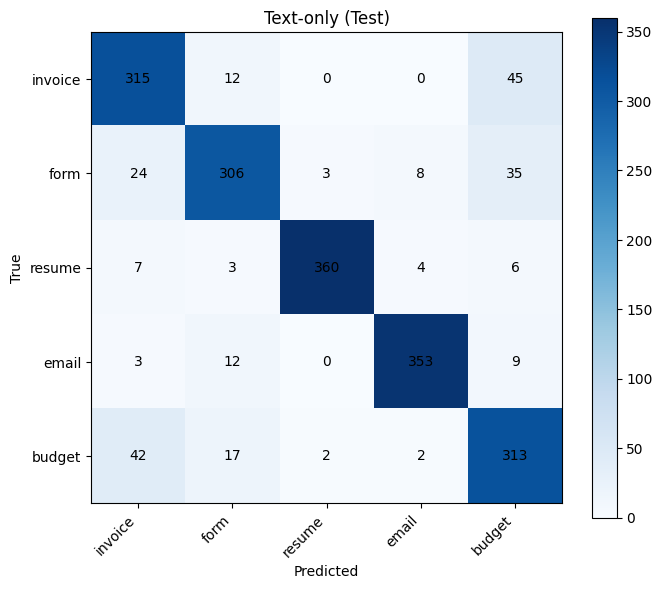

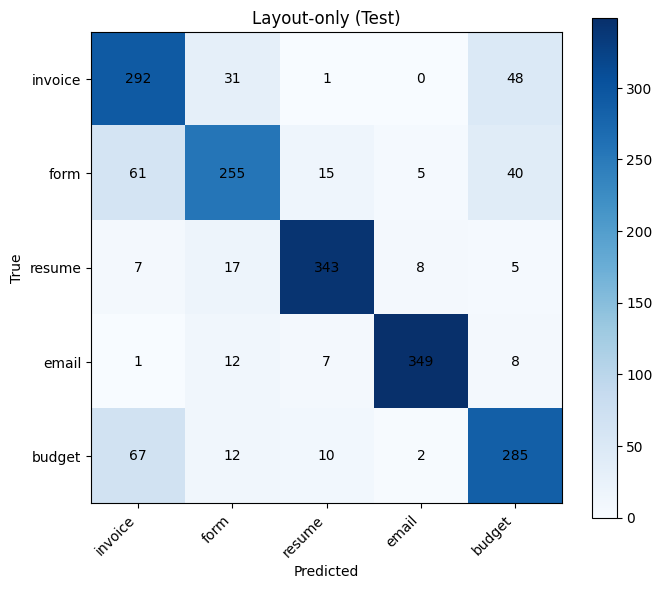

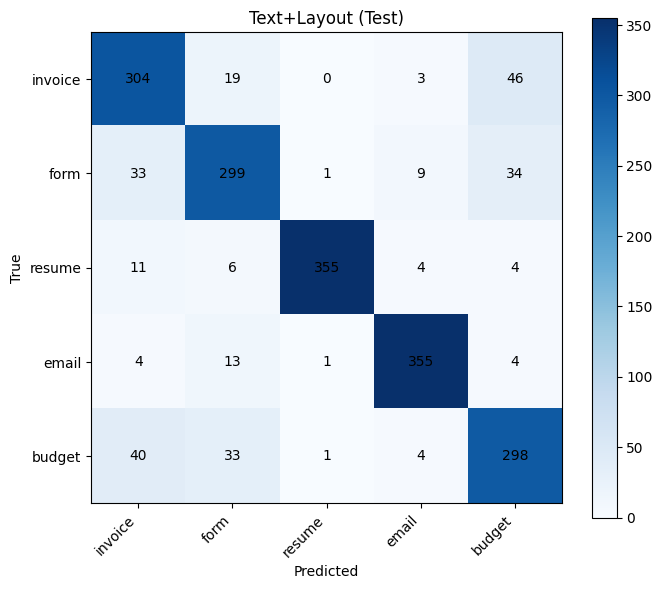

In [17]:
cm_text = confusion_matrix_df(y_test, y_test_pred_text, LABELS)
cm_layout = confusion_matrix_df(y_test, y_test_pred_layout, LABELS)
cm_combo = confusion_matrix_df(y_test, y_test_pred_combo, LABELS)

plot_confusion_matrix(cm_text, 'Text-only (Test)', save_path=fig_dir / 'cm_text_only_test.png')
plot_confusion_matrix(cm_layout, 'Layout-only (Test)', save_path=fig_dir / 'cm_layout_only_test.png')
plot_confusion_matrix(cm_combo, 'Text+Layout (Test)', save_path=fig_dir / 'cm_text_layout_test.png')

## Error Analysis (Focus: invoice confusions)

In [18]:
err_df = pd.DataFrame({
    'doc_id': test_text_df['doc_id'],
    'true': y_test,
    'pred': y_test_pred_combo,
    'text': test_text_df['ocr_text'],
})
invoice_confusions = err_df[(err_df['true']=='invoice') & (err_df['pred']!='invoice')].head(5)
invoice_confusions[['doc_id','true','pred']]

,doc_id,true,pred
1133,doc_00035043,invoice,budget
1134,doc_00035045,invoice,form
1139,doc_00035076,invoice,budget
1143,doc_00035114,invoice,form
1144,doc_00035115,invoice,budget


In [19]:
for _, r in invoice_confusions.iterrows():
    print('---')
    print('doc_id:', r['doc_id'], 'true:', r['true'], 'pred:', r['pred'])
    print(r['text'][:800])

---
doc_id: doc_00035043 true: invoice pred: budget
Eine 5
' cate +
saa
Hi &
sr z
Ee i
E gs
: E gz 8
B <= z
| Bg ys %
| IE Se EB 4
S85 ps :
BS o2R
RS saugee
: rg fet s8
gesese :
lp Bassas . :
og euad
fi tt x:
Lg iq ggekee aS s
Eanes ~
Ras FF * i
ea
---
doc_id: doc_00035045 true: invoice pred: form
24.89 02:48 PM 7 POT
PROMOTIONAL MARKETING TNC
Vad WEAEHUAOR STREET ,ENIEAGO,IULINGI® COELD.F1EINAS ONDE %
QvOTATTON
fOr Mr. Jim Bowling DATEL 1/24/89
Field Marketing Menager
R.J. Reynolds Tobaceo Company JOB Mor 07978-D
401 N, Mein street
Wineton-Salem, NC 27102 PROTEOT: Camel dpring Rasort
Program Execution
——
| DESCRIPTION:
Yor program management and execution of tha Camel spring Resort
Program in Daytena Beach, Piorida from March 12, 1989 through March
25, 1989 including the following:
I. Sameoth Movag" = Execution
A. Performance pay for Snooth Moves,
emcee, equipment (sound and lights),
technicians, assistants, and
Gostumed camel for tvo weeks. « . . « . « $28,800,
B, -Expensex for the a

## Feature Interpretation

,feature,importance
24,top_region_text_density,0.034753
54,header_block_prominence,0.034316
29,top_left_density,0.028696
9,avg_chars_per_line,0.026772
33,avg_line_length_chars,0.026110
8,avg_chars_per_word,0.025599
5,median_word_confidence,0.024246
6,low_confidence_word_ratio,0.023725
63,resume_anchor_count,0.023530
4,avg_word_confidence,0.023300


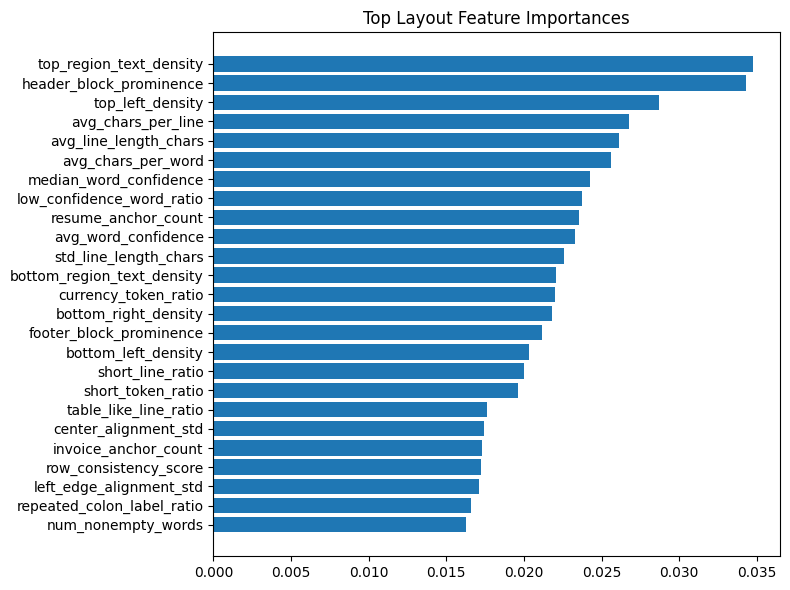

In [20]:
if hasattr(layout_model, 'feature_importances_'):
    imp = pd.DataFrame({'feature': layout_cols, 'importance': layout_model.feature_importances_}).sort_values('importance', ascending=False).head(25)
    display(imp)
    plt.figure(figsize=(8, 6))
    plt.barh(imp['feature'][::-1], imp['importance'][::-1])
    plt.title('Top Layout Feature Importances')
    plt.tight_layout()
    plt.savefig(fig_dir / 'layout_feature_importance_top25.png', dpi=140, bbox_inches='tight')
else:
    print('Model does not expose feature_importances_.')

## Save Predictions and Reports

In [21]:
# validation predictions
pred_text_val = build_prediction_table(val_text_df['doc_id'], y_val, y_val_pred_text, 'val', 'text_only', LABELS, p_val_text)
pred_layout_val = build_prediction_table(val_text_df['doc_id'], y_val, y_val_pred_layout, 'val', 'layout_only', LABELS, p_val_layout)
pred_combo_val = build_prediction_table(val_text_df['doc_id'], y_val, y_val_pred_combo, 'val', 'text_layout', LABELS, p_val_combo)

pred_text_val.to_csv(pred_dir / 'text_only_val_predictions.csv', index=False)
pred_layout_val.to_csv(pred_dir / 'layout_only_val_predictions.csv', index=False)
pred_combo_val.to_csv(pred_dir / 'text_layout_val_predictions.csv', index=False)

# test predictions
pred_text_test = build_prediction_table(test_text_df['doc_id'], y_test, y_test_pred_text, 'test', 'text_only', LABELS, p_test_text)
pred_layout_test = build_prediction_table(test_text_df['doc_id'], y_test, y_test_pred_layout, 'test', 'layout_only', LABELS, p_test_layout)
pred_combo_test = build_prediction_table(test_text_df['doc_id'], y_test, y_test_pred_combo, 'test', 'text_layout', LABELS, p_test_combo)

pred_text_test.to_csv(pred_dir / 'text_only_test_predictions.csv', index=False)
pred_layout_test.to_csv(pred_dir / 'layout_only_test_predictions.csv', index=False)
pred_combo_test.to_csv(pred_dir / 'text_layout_test_predictions.csv', index=False)

# metrics tables
pd.concat([metrics_dict_to_frame(val_metrics_text,'text_only','val'), metrics_dict_to_frame(test_metrics_text,'text_only','test')], ignore_index=True).to_csv(table_dir / 'text_only_metrics.csv', index=False)
pd.concat([metrics_dict_to_frame(val_metrics_layout,'layout_only','val'), metrics_dict_to_frame(test_metrics_layout,'layout_only','test')], ignore_index=True).to_csv(table_dir / 'layout_only_metrics.csv', index=False)
pd.concat([metrics_dict_to_frame(val_metrics_combo,'text_layout','val'), metrics_dict_to_frame(test_metrics_combo,'text_layout','test')], ignore_index=True).to_csv(table_dir / 'text_layout_metrics.csv', index=False)

# classification reports
classification_report_df(y_test, y_test_pred_text, LABELS).to_csv(table_dir / 'text_only_classification_report_test.csv')
classification_report_df(y_test, y_test_pred_layout, LABELS).to_csv(table_dir / 'layout_only_classification_report_test.csv')
classification_report_df(y_test, y_test_pred_combo, LABELS).to_csv(table_dir / 'text_layout_classification_report_test.csv')

## Save Models / Vectorizers

In [22]:
save_model_bundle(text_model, models_dir / 'text_only_model.joblib', word_vectorizer=word_vec, char_vectorizer=char_vec)
save_model_bundle(layout_model, models_dir / 'layout_only_model.joblib', imputer=layout_imputer, scaler=layout_scaler, layout_feature_cols=layout_cols)
save_model_bundle(text_layout_model, models_dir / 'text_layout_model.joblib', word_vectorizer=word_vec, char_vectorizer=char_vec, imputer=layout_imputer, scaler=layout_scaler, layout_feature_cols=layout_cols)

# Save compact summary artifact
summary = {
    'selected_model_name': selected_model_name,
    'val_ranking': val_table.to_dict(orient='records'),
    'test_metrics': test_table.to_dict(orient='records'),
}
with open(table_dir / 'layout_model_selection_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)

## Conclusion
- Compare macro F1 and invoice recall across text-only, layout-only, and text+layout.
- If text+layout wins on validation and test, keep it as Person 2 candidate architecture.
- Layout features are especially useful for invoice-vs-budget and invoice-vs-form confusion patterns.